# geodesy_stokes corrigido final

O erro `unexpected keyword argument 'exclude_singularity'` ocorreu porque o Python ainda estava carregando uma versão antiga de `geodesy/stokes.py`.

Substitua o arquivo `geodesy/stokes.py` pelo arquivo `stokes_corrigido.py` enviado aqui, renomeando-o para `stokes.py`. Depois reinicie o kernel e execute tudo desde o início.


In [19]:
import os, sys, inspect, importlib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
current_dir = Path.cwd()
if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
import geodesy
from geodesy import stokes, constants
importlib.reload(stokes)
print("Arquivo stokes.py usado:", stokes.__file__)
print("Assinatura stokes_integral_point:", inspect.signature(stokes.stokes_integral_point))
print("Assinatura stokes_integral_grid:", inspect.signature(stokes.stokes_integral_grid))


Arquivo stokes.py usado: C:\Users\Usuario\Python_Notebooks\python-modeling\geophysics\geodesy\stokes.py
Assinatura stokes_integral_point: (lat0, lon0, lat, lon, gravity_anomaly_mgal, cell_area_spherical, R=6371008.8, gamma=9.7803253359, degrees=True, exclude_singularity=True, min_psi=1e-10)
Assinatura stokes_integral_grid: (lat_grid, lon_grid, gravity_anomaly_mgal, dlat_deg=None, dlon_deg=None, R=6371008.8, gamma=9.7803253359, exclude_singularity=True, min_psi=1e-10)


psi: [0.         0.00493292 0.0242244  0.054282   0.09212569]
distância km: [  0.          31.42770709 154.33387968 345.83107158 586.93360376]


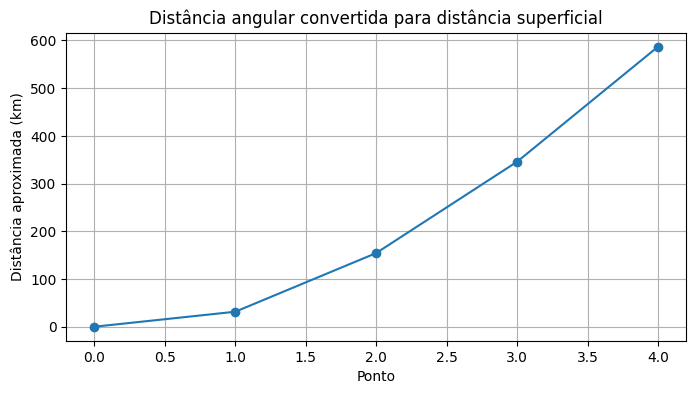

In [20]:
# 1. DISTÂNCIA ANGULAR ESFÉRICA
lat0, lon0 = -3.2, -52.2
lat_points = np.array([-3.2, -3.0, -2.5, -1.0, 0.0])
lon_points = np.array([-52.2, -52.0, -51.0, -50.0, -48.0])
psi = stokes.spherical_distance(lat0, lon0, lat_points, lon_points, degrees=True)
print("psi:", psi)
print("distância km:", psi * constants.MEAN_EARTH_RADIUS / 1000)
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(psi)), psi * constants.MEAN_EARTH_RADIUS / 1000, marker="o")
plt.xlabel("Ponto"); plt.ylabel("Distância aproximada (km)")
plt.title("Distância angular convertida para distância superficial")
plt.grid(True); plt.show()


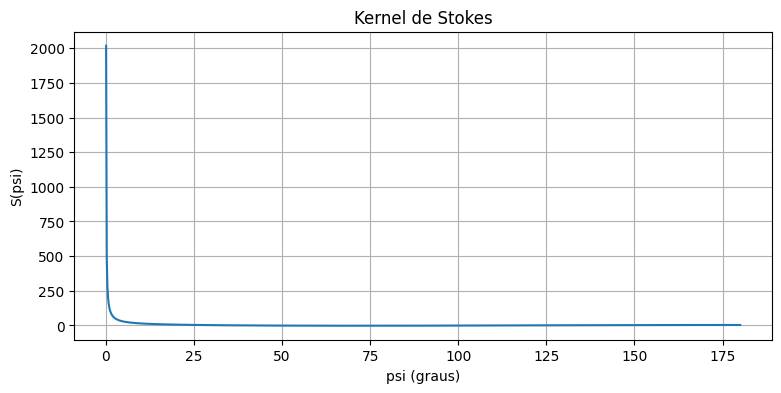

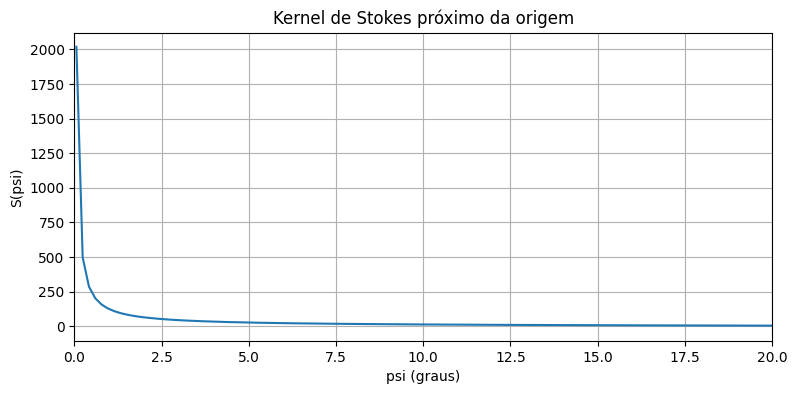

In [21]:
# 2. KERNEL DE STOKES
psi_values = np.linspace(0.001, np.pi, 1000)
S_values = stokes.stokes_kernel(psi_values)
plt.figure(figsize=(9,4))
plt.plot(np.rad2deg(psi_values), S_values)
plt.xlabel("psi (graus)"); plt.ylabel("S(psi)")
plt.title("Kernel de Stokes"); plt.grid(True); plt.show()
plt.figure(figsize=(9,4))
plt.plot(np.rad2deg(psi_values), S_values)
plt.xlim(0,20); plt.xlabel("psi (graus)"); plt.ylabel("S(psi)")
plt.title("Kernel de Stokes próximo da origem"); plt.grid(True); plt.show()


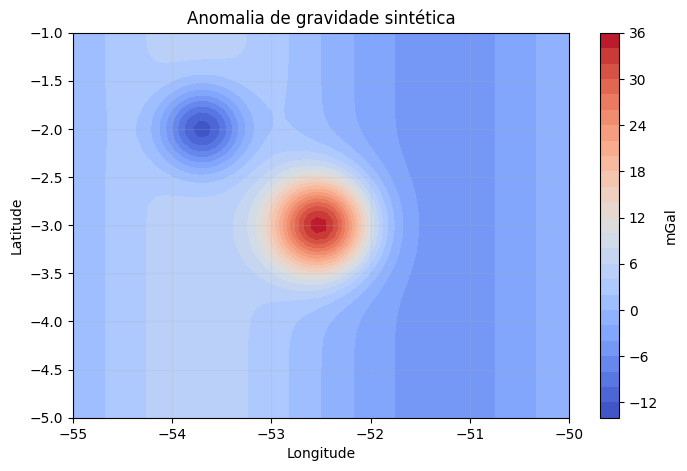

In [22]:
# 3. GRADE SINTÉTICA REGIONAL
lon = np.linspace(-55, -50, 60)
lat = np.linspace(-5, -1, 50)
LON, LAT = np.meshgrid(lon, lat)
DG = (35*np.exp(-((LON+52.5)**2+(LAT+3.0)**2)/0.25)
      -18*np.exp(-((LON+53.7)**2+(LAT+2.0)**2)/0.18)
      +5*np.sin((LON+55)*2*np.pi/5))
plt.figure(figsize=(8,5))
c=plt.contourf(LON,LAT,DG,levels=30,cmap="coolwarm")
plt.colorbar(c,label="mGal"); plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Anomalia de gravidade sintética"); plt.grid(alpha=.2); plt.show()


In [23]:
# 4. STOKES EM UM PONTO
lat_c = np.nanmean(LAT); lon_c = np.nanmean(LON)
dlat_deg = np.abs(lat[1]-lat[0]); dlon_deg = np.abs(lon[1]-lon[0])
cell_area_spherical = np.cos(np.deg2rad(LAT))*np.deg2rad(dlat_deg)*np.deg2rad(dlon_deg)
N_point = stokes.stokes_integral_point(
    lat_c, lon_c, LAT.ravel(), LON.ravel(), DG.ravel(), cell_area_spherical.ravel(),
    exclude_singularity=True
)
print("lat =", lat_c); print("lon =", lon_c); print("N =", N_point, "m")


lat = -3.0
lon = -52.5
N = 1.5993892501055698 m


(15, 8) -63369.114484676174 90763.40851139363


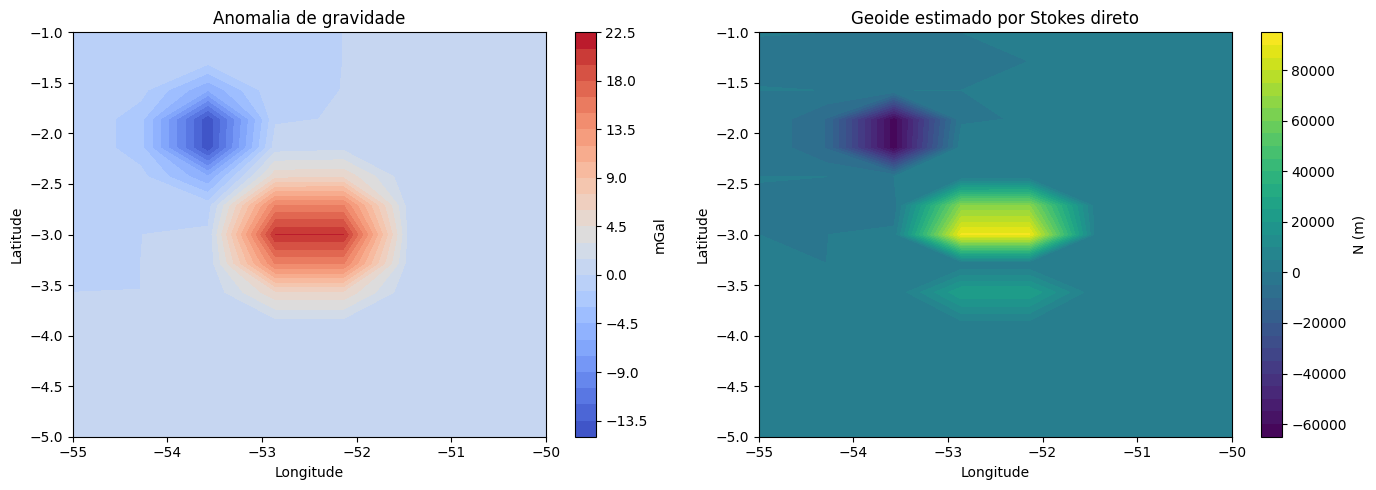

In [26]:
# 5. STOKES EM GRADE PEQUENA
lon_small = np.linspace(-55, -50, 8)
lat_small = np.linspace(-5, -1, 15)
LON_S, LAT_S = np.meshgrid(lon_small, lat_small)
DG_S = (35*np.exp(-((LON_S+52.5)**2+(LAT_S+3.0)**2)/0.25)
        -18*np.exp(-((LON_S+53.7)**2+(LAT_S+2.0)**2)/0.18))
N_STOKES_S = stokes.stokes_integral_grid(
    LAT_S, LON_S, DG_S,
    dlat_deg=np.abs(lat_small[1]-lat_small[0]),
    dlon_deg=np.abs(lon_small[1]-lon_small[0]),
    exclude_singularity=True
)
print(N_STOKES_S.shape, np.nanmin(N_STOKES_S), np.nanmax(N_STOKES_S))
plt.figure(figsize=(14,5))
plt.subplot(1,2,1); c1=plt.contourf(LON_S,LAT_S,DG_S,levels=30,cmap="coolwarm")
plt.colorbar(c1,label="mGal"); plt.title("Anomalia de gravidade")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.subplot(1,2,2); c2=plt.contourf(LON_S,LAT_S,N_STOKES_S,levels=30)
plt.colorbar(c2,label="N (m)"); plt.title("Geoide estimado por Stokes direto")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()


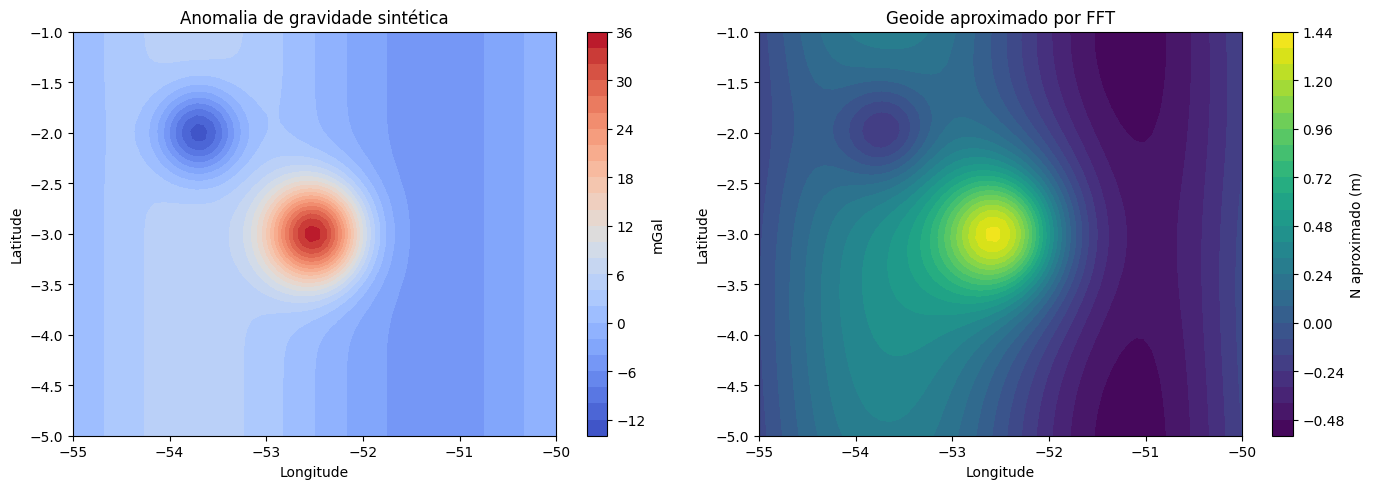

In [27]:
# 6. STOKES PLANAR APROXIMADO VIA FFT
lat_mean = np.nanmean(lat)
dx = np.abs(lon[1]-lon[0])*111000*np.cos(np.deg2rad(lat_mean))
dy = np.abs(lat[1]-lat[0])*111000
N_FFT = stokes.planar_stokes_fft_approx(DG, dx=dx, dy=dy)
plt.figure(figsize=(14,5))
plt.subplot(1,2,1); c1=plt.contourf(LON,LAT,DG,levels=30,cmap="coolwarm")
plt.colorbar(c1,label="mGal"); plt.title("Anomalia de gravidade sintética")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.subplot(1,2,2); c2=plt.contourf(LON,LAT,N_FFT,levels=30)
plt.colorbar(c2,label="N aproximado (m)"); plt.title("Geoide aproximado por FFT")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()


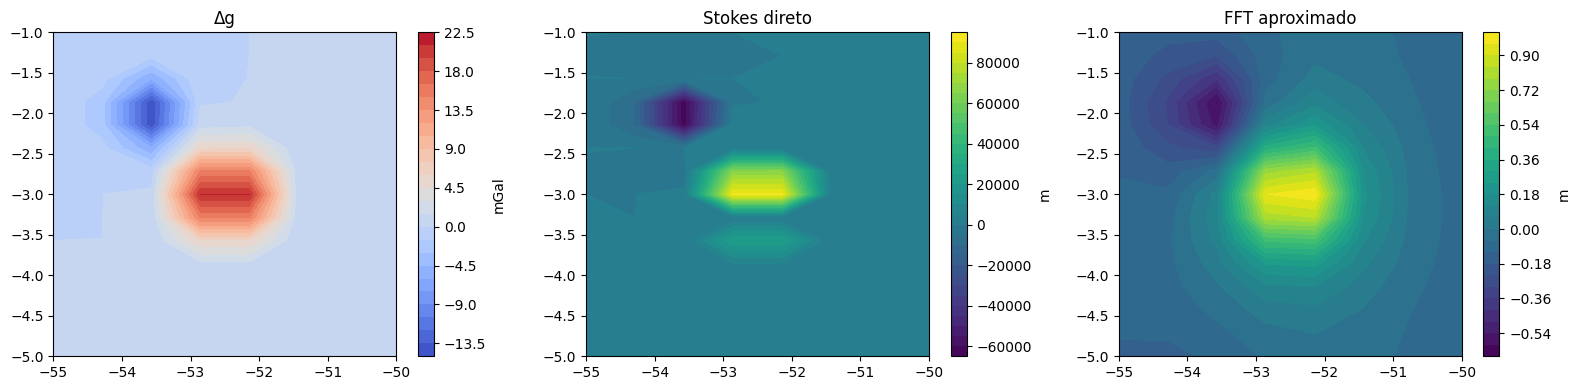

RMSE: 16980.078592629492


In [28]:
# 7. COMPARAÇÃO EM SUBGRADE
dx_s = np.abs(lon_small[1]-lon_small[0])*111000*np.cos(np.deg2rad(np.nanmean(lat_small)))
dy_s = np.abs(lat_small[1]-lat_small[0])*111000
N_FFT_S = stokes.planar_stokes_fft_approx(DG_S, dx=dx_s, dy=dy_s)
DIFF_METHODS = N_STOKES_S - N_FFT_S
plt.figure(figsize=(16,4))
plt.subplot(1,3,1); c1=plt.contourf(LON_S,LAT_S,DG_S,levels=30,cmap="coolwarm")
plt.colorbar(c1,label="mGal"); plt.title("Δg")
plt.subplot(1,3,2); c2=plt.contourf(LON_S,LAT_S,N_STOKES_S,levels=30)
plt.colorbar(c2,label="m"); plt.title("Stokes direto")
plt.subplot(1,3,3); c3=plt.contourf(LON_S,LAT_S,N_FFT_S,levels=30)
plt.colorbar(c3,label="m"); plt.title("FFT aproximado")
plt.tight_layout(); plt.show()
print("RMSE:", np.sqrt(np.nanmean(DIFF_METHODS**2)))


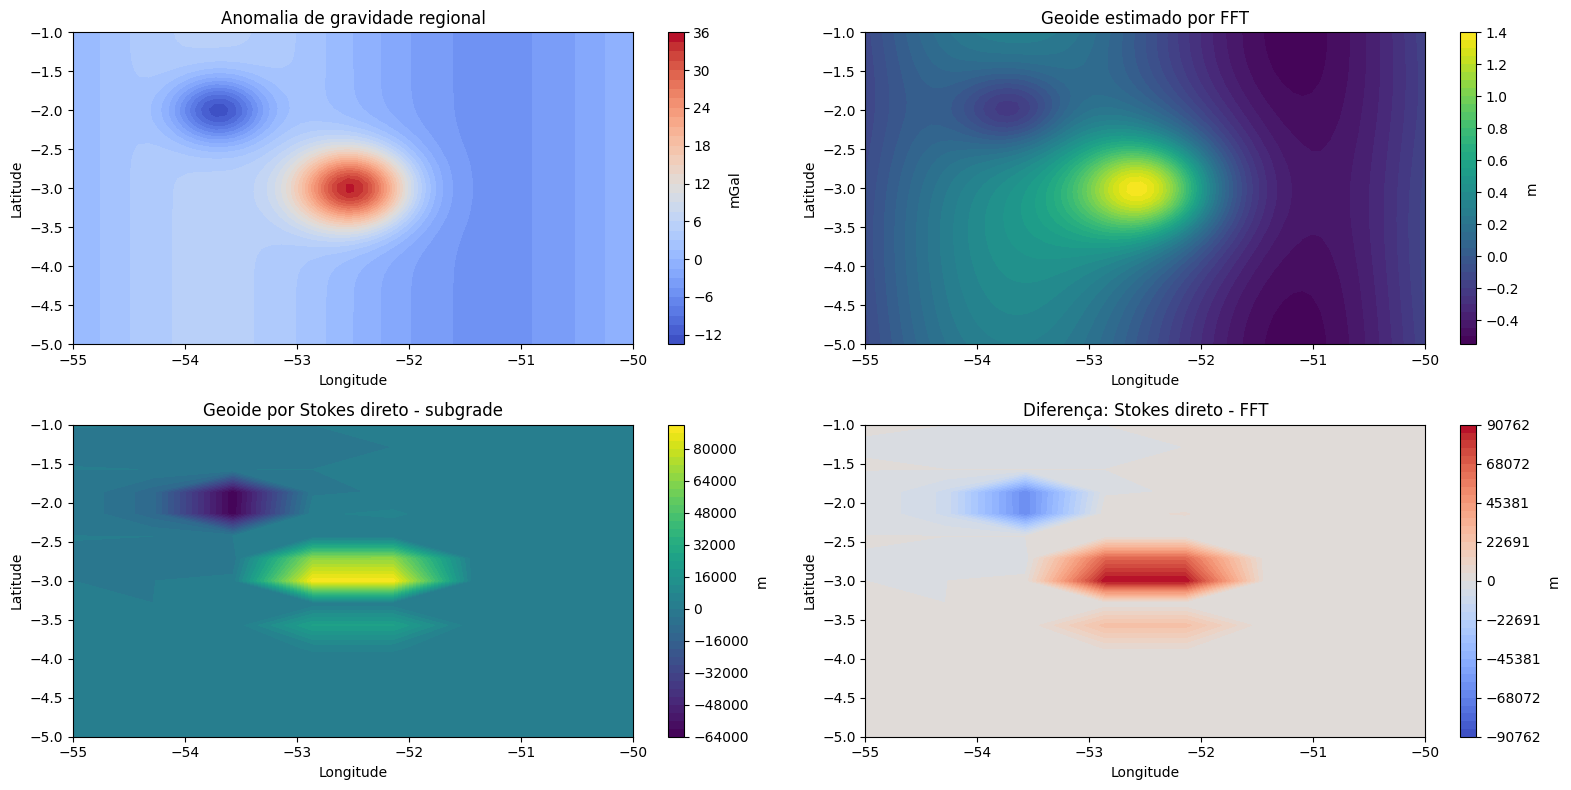

In [29]:
# 8. PAINEL REGIONAL: ANOMALIA E GEOIDE
plt.figure(figsize=(16,8))
plt.subplot(2,2,1); c1=plt.contourf(LON,LAT,DG,levels=40,cmap="coolwarm")
plt.colorbar(c1,label="mGal"); plt.title("Anomalia de gravidade regional")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.subplot(2,2,2); c2=plt.contourf(LON,LAT,N_FFT,levels=40)
plt.colorbar(c2,label="m"); plt.title("Geoide estimado por FFT")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.subplot(2,2,3); c3=plt.contourf(LON_S,LAT_S,N_STOKES_S,levels=40)
plt.colorbar(c3,label="m"); plt.title("Geoide por Stokes direto - subgrade")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.subplot(2,2,4); vmax=np.nanmax(np.abs(DIFF_METHODS))
c4=plt.contourf(LON_S,LAT_S,DIFF_METHODS,levels=np.linspace(-vmax,vmax,41),cmap="coolwarm")
plt.colorbar(c4,label="m"); plt.title("Diferença: Stokes direto - FFT")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()


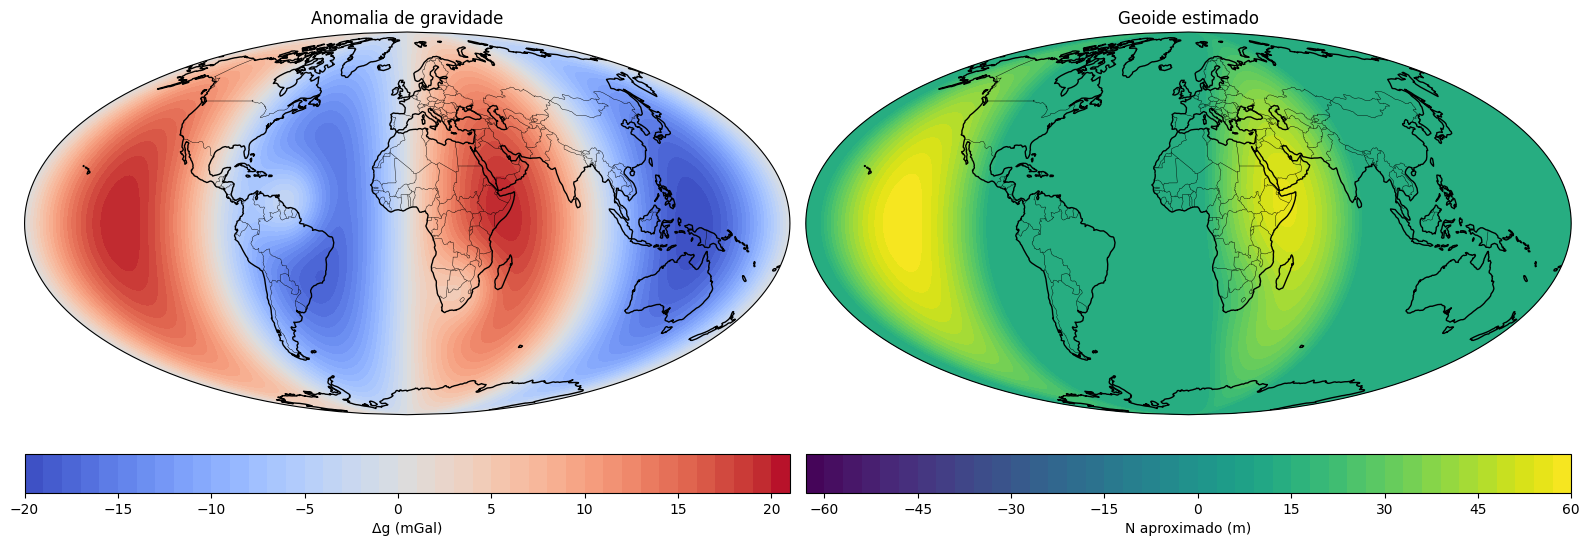

In [30]:
# 9. MAPAS GLOBAIS COM CARTOPY / MOLLWEIDE: ANOMALIA E GEOIDE
import cartopy.crs as ccrs
import cartopy.feature as cfeature
lon_g = np.arange(-180, 181, 1.0)
lat_g = np.arange(-90, 91, 1.0)
LON_G, LAT_G = np.meshgrid(lon_g, lat_g)
DG_G = (20*np.sin(np.deg2rad(2*LON_G))*np.cos(np.deg2rad(LAT_G))
        +15*np.exp(-((LON_G+55)**2+(LAT_G-8)**2)/300)
        -10*np.exp(-((LON_G-30)**2+(LAT_G+25)**2)/260))
N_G = stokes.planar_stokes_fft_approx(DG_G, dx=111000, dy=111000)
fig = plt.figure(figsize=(16,6))
ax1 = plt.subplot(1,2,1,projection=ccrs.Mollweide())
cf1=ax1.contourf(LON_G,LAT_G,DG_G,levels=40,transform=ccrs.PlateCarree(),cmap="coolwarm")
ax1.coastlines(); ax1.add_feature(cfeature.BORDERS, linewidth=.3); ax1.set_global()
plt.colorbar(cf1,ax=ax1,orientation="horizontal",pad=.07,label="Δg (mGal)")
ax1.set_title("Anomalia de gravidade")
ax2 = plt.subplot(1,2,2,projection=ccrs.Mollweide())
cf2=ax2.contourf(LON_G,LAT_G,N_G,levels=40,transform=ccrs.PlateCarree())
ax2.coastlines(); ax2.add_feature(cfeature.BORDERS, linewidth=.3); ax2.set_global()
plt.colorbar(cf2,ax=ax2,orientation="horizontal",pad=.07,label="N aproximado (m)")
ax2.set_title("Geoide estimado")
plt.tight_layout(); plt.show()
